<a href="https://colab.research.google.com/github/Shopnil392/bdFlag/blob/main/ham_vs_spam_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string



In [45]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,

)


In [46]:
df = pd.read_csv('spam.csv', encoding='latin-1')

df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Holla!..its loaded!
Shape: (5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       5572 non-null   object
 1   message     5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
label            0
message          0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64
403
(5169, 5)
label
ham     4516
spam     653
Name: count, dtype: int64


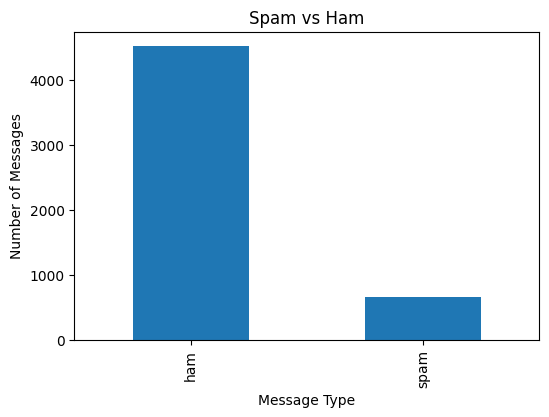

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


length of training samples: 4135

and length of esting samples: 1034
new TF-IDF training shape:
(4135, 5000)
new TF-IDF testing shape:
(1034, 5000)
model train done
Accuracy:
0.9671179883945842
Classification Report
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.75      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034

hey enter a message: won
Prediction: SPAM
Estimated probability in percentages: 80.36 %


In [47]:
df = df.rename(columns={'v1': 'label', 'v2': 'message'})
print("Holla!..its loaded!")
print("Shape:", df.shape)
df.head()


#data viewing

df.info()
print(df.isnull().sum())
print(df.duplicated().sum())
df = df.drop_duplicates()
#now view the after drop
print(df.shape)

print(df["label"].value_counts())



#showing a graph
plt.figure(figsize=(6,4))

df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()


#label to num conv
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})
df.head()

#making text clean func
def clean_text(text):

    #low
    text = text.lower()

    #url remo
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Re punc
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    #re num
    text = re.sub(r"\d+", "", text)

    #re spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_message"] = df["message"].apply(clean_text)

display(
    df[["message", "clean_message"]].head()
)







#for split taking variable

X = df["clean_message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("length of training samples:", len(X_train))
print("\nand length of esting samples:", len(X_test))


#now tf-idf using vactorizer to make number
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("new TF-IDF training shape:")
print(X_train_tfidf.shape)

print("new TF-IDF testing shape:")
print(X_test_tfidf.shape)

#now creating the model using multinomial

model = MultinomialNB()






model.fit(
    X_train_tfidf,
    y_train
)

print("model train done")

#trying to predict by model
y_pred = model.predict(
    X_test_tfidf
)


#now test accuracy by getting the val
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:")
print(accuracy)




print("Classification Report")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)




#function for check the prediction of the model


def predict_message(message):

    #1st clean the msg
    cleaned = clean_text(message)

    #make to TF-IDF
    vectorized = vectorizer.transform(
        [cleaned]
    )

    #Predict
    prediction = model.predict(
        vectorized
    )[0]

    #Probability check
    probabilities = model.predict_proba(
        vectorized
    )[0]

    if prediction == 1:

        result = "SPAM"
        confidence = probabilities[1]

    else:

        result = "NOT SPAM"
        confidence = probabilities[0]

    return result, confidence



#now test

message = input(
    "hey enter a message: "
)

result, confidence = predict_message(
     message
)

print("Prediction:", result)

print(
    "Estimated probability in percentages:",
    round(confidence * 100, 2),
    "%"
)







